In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
from pathlib import Path

# Ruta raíz del proyecto en Drive
PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models")

# Carpetas principales
NOTEBOOKS_DIR = PROJECT_PATH / "notebooks"
SRC_DIR = PROJECT_PATH / "src"
CHECKPOINTS_DIR = PROJECT_PATH / "checkpoints"
RESULTS_DIR = PROJECT_PATH / "results"

# Añadir src al path para poder importar los .py
sys.path.insert(0, str(SRC_DIR))

# Crear carpetas si no existen
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH =", PROJECT_PATH)
print("SRC_DIR =", SRC_DIR)
print("CHECKPOINTS_DIR =", CHECKPOINTS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_PATH = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
SRC_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src
CHECKPOINTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints
RESULTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/results


In [ ]:

from pathlib import Path
from functools import partial

import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.optim import Adam
import tqdm



In [ ]:
# Reproducibility
_ = torch.manual_seed(123)
np.random.seed(123)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

checkpoint_path = CHECKPOINTS_DIR / "ou_colored_mnist_conditional_cosine.pth"
print("Checkpoint path:", checkpoint_path)



Device: cuda
Checkpoint path: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_colored_mnist_conditional_cosine.pth


In [ ]:
from colored_mnist_dataset import (
    ColoredMNIST,
    get_color_names,
    get_color_to_id,
)

color_names = get_color_names()
color_to_id = get_color_to_id()

print("Available colors:", color_names)
print("Color to id:", color_to_id)


mnist_train = datasets.MNIST(
    root=os.path.join(PROJECT_PATH, "data"),
    train=True,
    download=True,
    transform=ToTensor(),
)

colored_train = ColoredMNIST(
    mnist_dataset=mnist_train,
    color_mode="random",
    seed=123,
)

print("Number of training images:", len(colored_train))
print("Number of colors:", len(color_names))

x_example, digit_example, color_example = colored_train[0]

print("Image shape:", x_example.shape)
print("Digit label:", digit_example)
print("Color label:", color_example)
print("Color name:", color_names[int(color_example)])

Available colors: ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'white']
Color to id: {'red': 0, 'green': 1, 'blue': 2, 'yellow': 3, 'cyan': 4, 'magenta': 5, 'white': 6}
Number of training images: 60000
Number of colors: 7
Image shape: torch.Size([3, 28, 28])
Digit label: tensor(5)
Color label: tensor(2)
Color name: blue


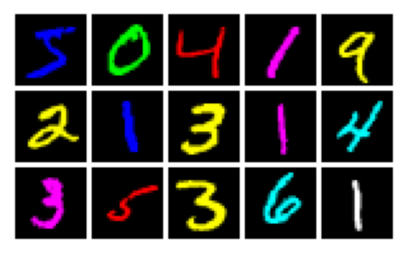

In [ ]:
from diffusion_utilities import plot_image_grid

n_rows = 3
n_cols = 5

example_images = [colored_train[i][0] for i in range(n_rows * n_cols)]

_ = plot_image_grid(
    images=example_images,
    figsize=(5, 5),
    n_rows=n_rows,
    n_cols=n_cols,
    normalize=True,
)

In [ ]:
from ou_utils import (
    cosine_beta_schedule,
    cosine_beta_integral,
    ou_sigma_t,
    ou_mu_t,
)

import diffusion_process as dfp

schedule_name = "cosine"

beta_schedule = partial(cosine_beta_schedule, s=0.008)
beta_integral = partial(cosine_beta_integral, s=0.008)

drift_coefficient = lambda x_t, t: -0.5 * beta_schedule(t)[:, None, None, None] * x_t
diffusion_coefficient = lambda t: torch.sqrt(beta_schedule(t))

mu_t = partial(ou_mu_t, beta_integral=beta_integral)
sigma_t = partial(ou_sigma_t, beta_integral=beta_integral)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

print("Diffusion process: OU")
print("Noise schedule:", schedule_name)

Diffusion process: OU
Noise schedule: cosine


In [ ]:
batch_size = 64
n_threads = 2

data_loader = DataLoader(
    colored_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=n_threads,
)

x_batch, digit_batch, color_batch = next(iter(data_loader))

print("x_batch shape:", x_batch.shape)
print("digit_batch shape:", digit_batch.shape)
print("color_batch shape:", color_batch.shape)

x_batch shape: torch.Size([64, 3, 28, 28])
digit_batch shape: torch.Size([64])
color_batch shape: torch.Size([64])


In [ ]:
from conditional_color_score_model import ConditionalColorScoreNet

score_model = ConditionalColorScoreNet(
    marginal_prob_std=sigma_t,
    num_digits=10,
    num_colors=len(color_names),
).to(device)

print(score_model.__class__.__name__)

ConditionalColorScoreNet


In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device)
score_model.load_state_dict(checkpoint)
score_model.eval()

print("Checkpoint loaded correctly from:", checkpoint_path)

Checkpoint loaded correctly from: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_colored_mnist_conditional_cosine.pth


In [ ]:
from conditional_color_training_utils import conditional_color_loss_function

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 150

tqdm_epoch = tqdm.trange(n_epochs)

for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0

    for x_0, digit_label, color_label in data_loader:
        x_0 = x_0.to(device)
        digit_label = digit_label.to(device)
        color_label = color_label.to(device)

        loss = conditional_color_loss_function(
            diffusion_process=diffusion_process,
            score_model=score_model,
            x_0=x_0,
            digit_label=digit_label,
            color_label=color_label,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x_0.shape[0]
        num_items += x_0.shape[0]

    avg_loss = avg_loss / num_items
    tqdm_epoch.set_description(f"Average Loss: {avg_loss:.5f}")

    torch.save(score_model.state_dict(), checkpoint_path)

print("Training finished.")
print("Checkpoint saved at:", checkpoint_path)

Average Loss: 44.64721: 100%|██████████| 150/150 [58:57<00:00, 23.58s/it]

Training finished.
Checkpoint saved at: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_colored_mnist_conditional_cosine.pth


In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device)
score_model.load_state_dict(checkpoint)
score_model.eval()

print("Checkpoint loaded correctly from:", checkpoint_path)

Checkpoint loaded correctly from: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_colored_mnist_conditional_cosine.pth


In [ ]:
from diffusion_utilities import plot_image_grid, plot_image_evolution

In [ ]:
def sample_conditional_color_ou_euler_maruyama(
    score_model,
    beta_schedule,
    target_digit,
    target_color_id,
    n_images,
    image_shape=(3, 28, 28),
    T=1.0,
    t_end=1.0e-3,
    n_steps=500,
    device="cpu",
):
    """
    Generate digit- and color-conditional samples using the reverse OU SDE
    and Euler-Maruyama integration.
    """

    x_t = torch.randn(n_images, *image_shape, device=device)

    digit_labels = torch.full(
        (n_images,),
        target_digit,
        dtype=torch.long,
        device=device,
    )

    color_labels = torch.full(
        (n_images,),
        target_color_id,
        dtype=torch.long,
        device=device,
    )

    times = torch.linspace(T, t_end, n_steps + 1, device=device)
    dt = times[1] - times[0]

    x_path = torch.empty(
        n_images,
        *image_shape,
        n_steps + 1,
        device=device,
        dtype=torch.float32,
    )

    x_path[..., 0] = x_t

    for n, t_scalar in enumerate(times[:-1]):
        t = torch.full((n_images,), t_scalar, device=device)

        beta_t = beta_schedule(t).view(-1, 1, 1, 1)
        drift = -0.5 * beta_t * x_t

        score = score_model(
            x_t,
            t,
            digit_labels,
            color_labels,
        )

        diffusion = torch.sqrt(beta_schedule(t)).view(-1, 1, 1, 1)
        z = torch.randn_like(x_t)

        x_t = (
            x_t
            + (drift - diffusion**2 * score) * dt
            + diffusion * torch.sqrt(torch.abs(dt)) * z
        )

        x_path[..., n + 1] = x_t

    return times, x_path

In [ ]:
target_digit = 7
target_color = "red"

target_color_id = color_to_id[target_color]

print("Target digit:", target_digit)
print("Target color:", target_color)
print("Target color id:", target_color_id)

Target digit: 7
Target color: red
Target color id: 0


In [ ]:
n_images = 16

with torch.no_grad():
    times, synthetic_images_t = sample_conditional_color_ou_euler_maruyama(
        score_model=score_model,
        beta_schedule=beta_schedule,
        target_digit=target_digit,
        target_color_id=target_color_id,
        n_images=n_images,
        image_shape=(3, 28, 28),
        T=1.0,
        t_end=1.0e-3,
        n_steps=500,
        device=device,
    )

print("synthetic_images_t shape:", synthetic_images_t.shape)

synthetic_images_t shape: torch.Size([16, 3, 28, 28, 501])


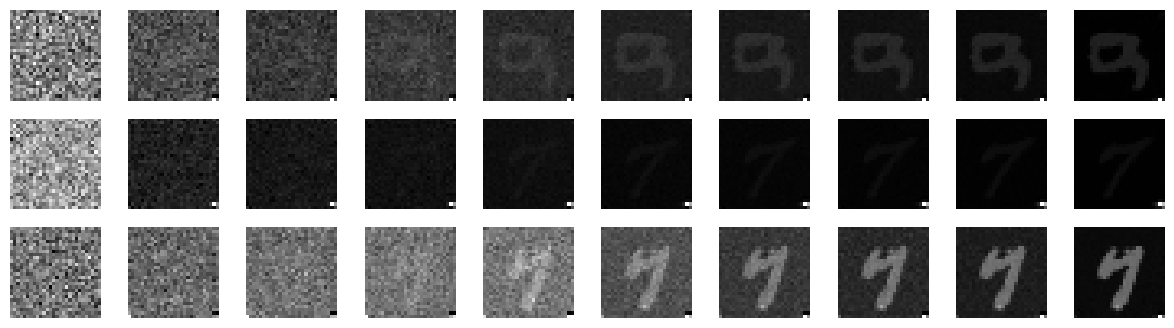

In [ ]:
_ = plot_image_evolution(
    images=synthetic_images_t.cpu(),
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

final_images = synthetic_images_t[..., -1]
final_images = torch.clamp(final_images, 0.0, 1.0).cpu()

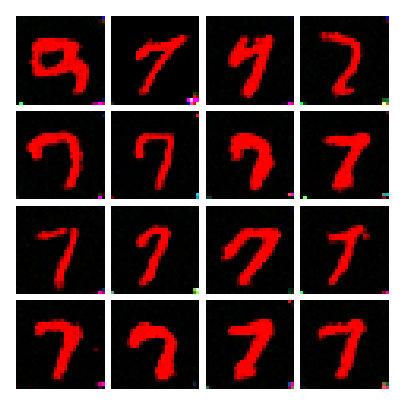

In [ ]:
_ = plot_image_grid(
    images=[final_images[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=4,
    n_cols=4,
    normalize=True,
)

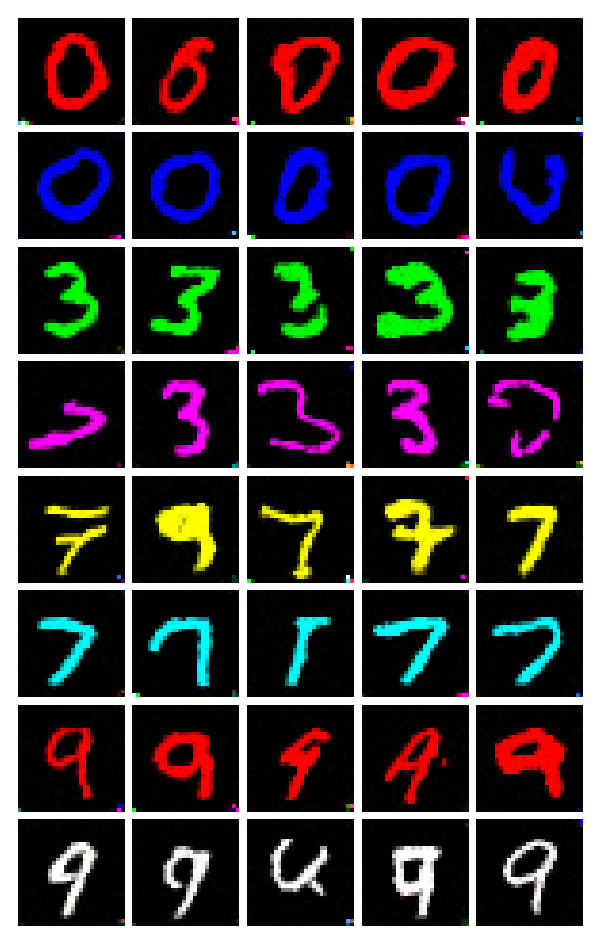

In [ ]:
conditions_to_compare = [
    (0, "red"),
    (0, "blue"),
    (3, "green"),
    (3, "magenta"),
    (7, "yellow"),
    (7, "cyan"),
    (9, "red"),
    (9, "white"),
]

images_per_condition = 5

comparison_images = []

with torch.no_grad():
    for digit, color_name in conditions_to_compare:
        color_id = color_to_id[color_name]

        _, synthetic_images_t_condition = sample_conditional_color_ou_euler_maruyama(
            score_model=score_model,
            beta_schedule=beta_schedule,
            target_digit=digit,
            target_color_id=color_id,
            n_images=images_per_condition,
            image_shape=(3, 28, 28),
            T=1.0,
            t_end=1.0e-3,
            n_steps=500,
            device=device,
        )

        final_images_condition = synthetic_images_t_condition[..., -1]
        final_images_condition = torch.clamp(final_images_condition, 0.0, 1.0).cpu()

        for i in range(images_per_condition):
            comparison_images.append(final_images_condition[i])

_ = plot_image_grid(
    images=comparison_images,
    figsize=(10, 12),
    n_rows=len(conditions_to_compare),
    n_cols=images_per_condition,
    normalize=True,
)

In [ ]:
for row, condition in enumerate(conditions_to_compare):
    print(f"Row {row}: digit={condition[0]}, color={condition[1]}")